In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")


In [2]:
data = pd.read_csv("mark.csv")  
data.head()


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [4]:
data.drop(columns=["Unnamed: 0", "id"], inplace=True)
data["Arrival Delay in Minutes"].fillna(data["Arrival Delay in Minutes"].median(), inplace=True)

data["satisfaction"] = data["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

data = pd.get_dummies(data, drop_first=True)

X = data.drop("satisfaction", axis=1)
y = data["satisfaction"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


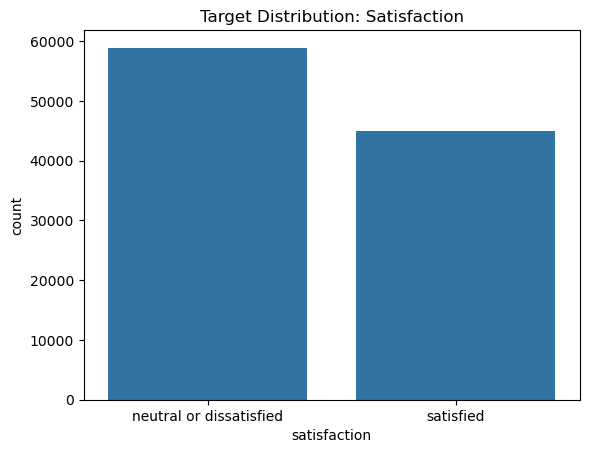

In [5]:
sns.countplot(x='satisfaction', data=pd.read_csv("mark.csv"))
plt.title("Target Distribution: Satisfaction")
plt.show()


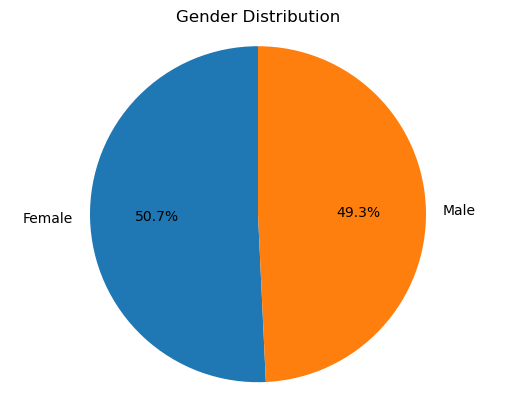

In [6]:
gender_counts = pd.read_csv("mark.csv")["Gender"].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.axis("equal")
plt.show()


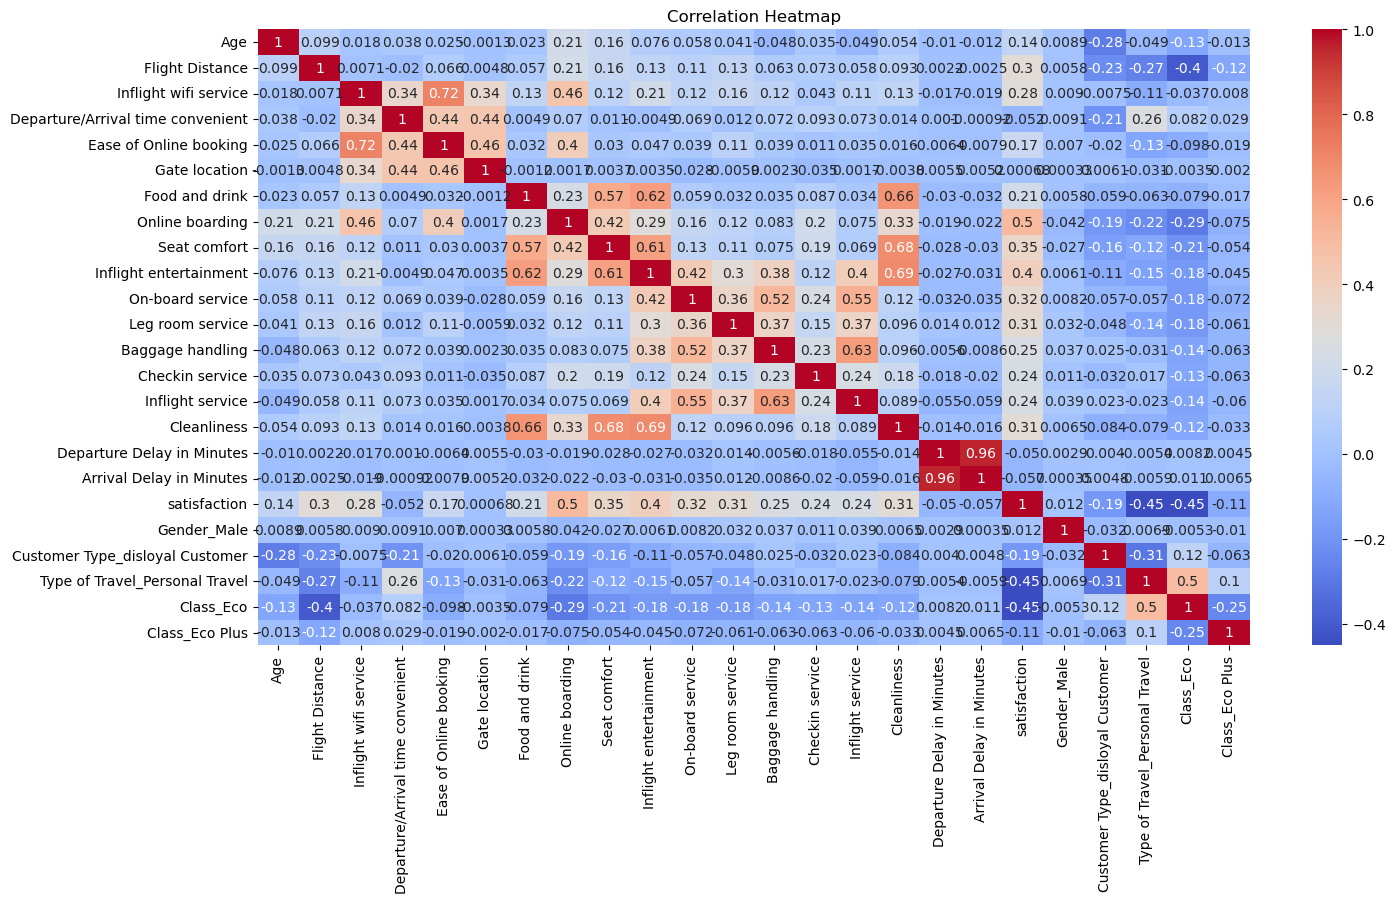

In [7]:
plt.figure(figsize=(16,8))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()


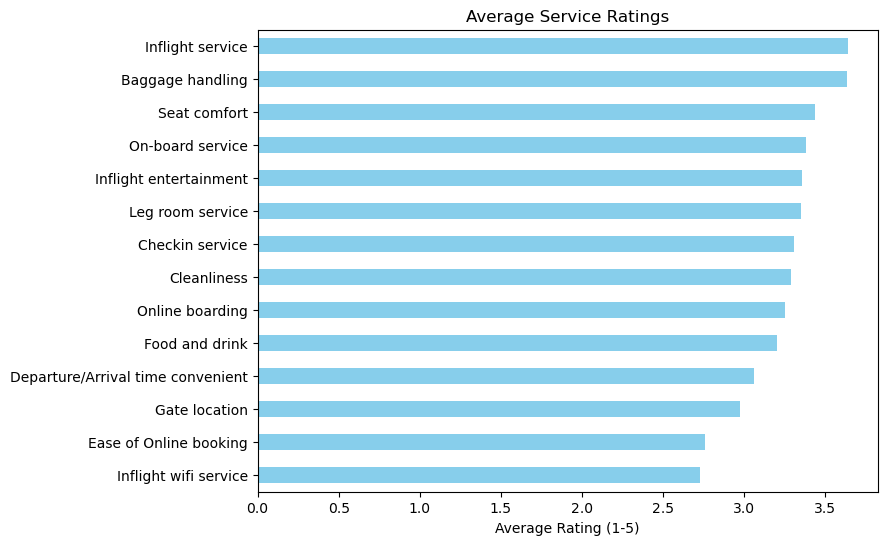

In [37]:
service_columns = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

service_means = data[service_columns].mean().sort_values()
plt.figure(figsize=(8,6))
service_means.plot(kind='barh', color='skyblue')
plt.title('Average Service Ratings')
plt.xlabel('Average Rating (1-5)')
plt.show()


# KNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
knn = KNeighborsClassifier()

In [13]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [15]:
y_pred = knn.predict(X_test)

In [16]:
accuracy_knn = accuracy_score(y_pred,y_test)
print('KNeighbors Classifier Accuracy',accuracy_knn)

KNeighbors Classifier Accuracy 0.9284923728405755


In [17]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94     12397
           1       0.88      0.95      0.91      8384

    accuracy                           0.93     20781
   macro avg       0.92      0.93      0.93     20781
weighted avg       0.93      0.93      0.93     20781



# Logistic Regression

In [18]:
lr = LogisticRegression()

In [20]:
lr.fit(X_train,y_train)

LogisticRegression()

In [22]:
pred1 = lr.predict(X_test)

In [23]:
accuracy_lr =accuracy_score(pred1,y_test)
print('Logistic Regression Accuracy',accuracy_lr)

Logistic Regression Accuracy 0.8765218228189211


In [24]:
print(classification_report(pred1,y_test))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89     12073
           1       0.84      0.87      0.86      8708

    accuracy                           0.88     20781
   macro avg       0.87      0.88      0.87     20781
weighted avg       0.88      0.88      0.88     20781



# Decision Tree Classifier

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred2 = dt.predict(X_test)

accuracy_dt =accuracy_score(pred2,y_test)
print('DecisionTreeClassifier Accuracy',accuracy_dt)

print(classification_report(pred2,y_test))

DecisionTreeClassifier Accuracy 0.9440835378470719
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     11603
           1       0.94      0.93      0.94      9178

    accuracy                           0.94     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.94      0.94      0.94     20781



# Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier()

RFC.fit(X_train,y_train)

pred3 = RFC.predict(X_test)

accuracy_rfc =accuracy_score(pred3,y_test)
print('Accuracy',accuracy_rfc)

print(classification_report(pred3,y_test))

Accuracy 0.9612626918820076
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     12030
           1       0.94      0.97      0.95      8751

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



# AdaBoostClassifier


In [30]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

accuracy_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", accuracy_ada)

print(classification_report(y_pred_ada,y_test))

AdaBoost Accuracy: 0.927963043164429
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     11876
           1       0.91      0.93      0.92      8905

    accuracy                           0.93     20781
   macro avg       0.93      0.93      0.93     20781
weighted avg       0.93      0.93      0.93     20781



# GaussianNB


In [34]:

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train,y_train)

pred4 = gnb.predict(X_test)

accuracy_gnb =accuracy_score(pred4,y_test)
print('GaussianNB Accuracy',accuracy_gnb)

accuracy_gnb =(pred4,y_test)
print('GaussianNB Accuracy',accuracy_gnb)

print(classification_report(pred4,y_test))

GaussianNB Accuracy 0.8605456907752274
GaussianNB Accuracy (array([0, 0, 0, ..., 0, 1, 0], dtype=int64), 80638    0
43398    0
32751    0
33571    0
71287    0
        ..
8158     0
53718    0
33319    0
99162    1
96811    1
Name: satisfaction, Length: 20781, dtype: int64)
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     12207
           1       0.81      0.86      0.84      8574

    accuracy                           0.86     20781
   macro avg       0.86      0.86      0.86     20781
weighted avg       0.86      0.86      0.86     20781



# GradientBoostingClassifier

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

In [41]:
gb = GradientBoostingClassifier(
    n_estimators=100,     
    learning_rate=0.1,   
    max_depth=3,          
    random_state=42
)

gb.fit(X_train, y_train)
y_pred7 = gb.predict(X_test)

accuracy_gb =accuracy_score(y_pred7,y_test)
print('GradientBoostingClassifier Accuracy',accuracy_gb)

print("Classification Report for Gradient Boosting Classifier:\n")
print(classification_report(y_test, y_pred))


GradientBoostingClassifier Accuracy 0.9407631971512439
Classification Report for Gradient Boosting Classifier:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     11713
           1       0.95      0.92      0.93      9068

    accuracy                           0.94     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.94      0.94      0.94     20781



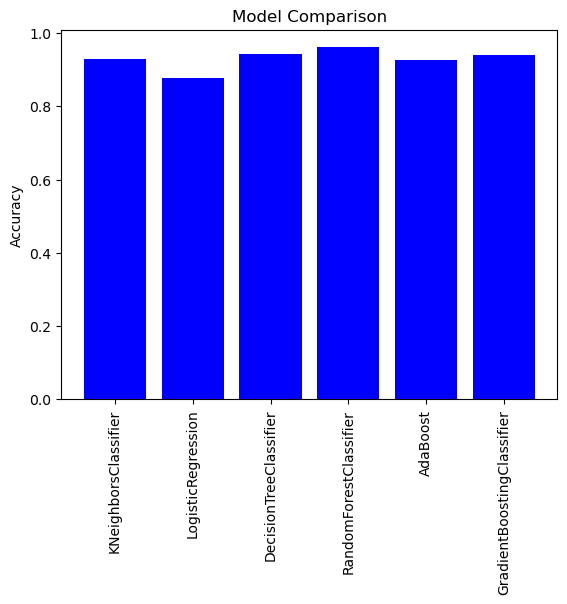

In [43]:
models = ['KNeighborsClassifier',"LogisticRegression",'DecisionTreeClassifier','RandomForestClassifier','AdaBoost','GradientBoostingClassifier']
scores = [accuracy_knn, accuracy_lr,accuracy_dt,accuracy_rfc,accuracy_ada,accuracy_gb]
plt.bar(models, scores, color = 'blue')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(rotation = 90)
plt.show()
